## License

This code is licensed under the Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0).  
You are free to use and modify the code for non-commercial research and educational purposes, provided that you give appropriate credit and distribute derivatives under the same license.


In [ ]:
# 📦 Imports & Konstanten
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.io as pio
pio.renderers.default = "notebook"

# Datei & Signalparameter
FILEPATH = "/BeyondSingleLeadEDR/raw_EASI_data/-55-2024-06-09-15-33-57.txt" #"/yourfilepath/yourfile.txt" # Pfad zur EKG-Datei

# speziell für die von Cardiosecur exportierten Dateien
SEP = ";"
COL_IS, COL_ES, COL_AS = "R", "M", "L"

FS = fs = 250

# anpassbar an zu analysierenden Abschnitt
START_SEC = 0
DURATION = 450 

In [2]:
# Probanden-ID extrahieren
# nur wenn der Dateiname das Format "-<ID>-YYYY-MM-DD-..." hat
import os, re

# Basename der Datei holen, z.B. "-50-2024-06-08-17-16-50.txt"
fname = os.path.basename(FILEPATH)

# Zahl zwischen zwei Bindestrichen extrahieren (z.B. "50" aus "-50-2024-...")
m = re.search(r"-(\d+)-", fname)
if m:
    PROBAND_ID = m.group(1)          # als String, z.B. "50"
    # optional auch als int:
    PROBAND_ID_INT = int(PROBAND_ID)
else:
    raise ValueError(f"Keine Probanden-ID im Dateinamen gefunden: {fname}")

print("Probanden-ID:", PROBAND_ID)

subject_id = f"S{PROBAND_ID}"


Probanden-ID: 55


In [3]:
# Datei laden & schneiden
df_raw_data = pd.read_csv(FILEPATH, sep=SEP) #DATAFRAME
start_idx = int(START_SEC * FS)
end_idx = start_idx + int(DURATION * FS)
df_raw_data_win = df_raw_data.iloc[start_idx:end_idx]

# ⛏ Rohsignale extrahieren
V_IS = df_raw_data_win[COL_IS].astype(float).to_numpy()
V_ES = df_raw_data_win[COL_ES].astype(float).to_numpy()
V_AS = df_raw_data_win[COL_AS].astype(float).to_numpy()

# Zeitvektor
t = np.arange(len(V_IS)) / FS

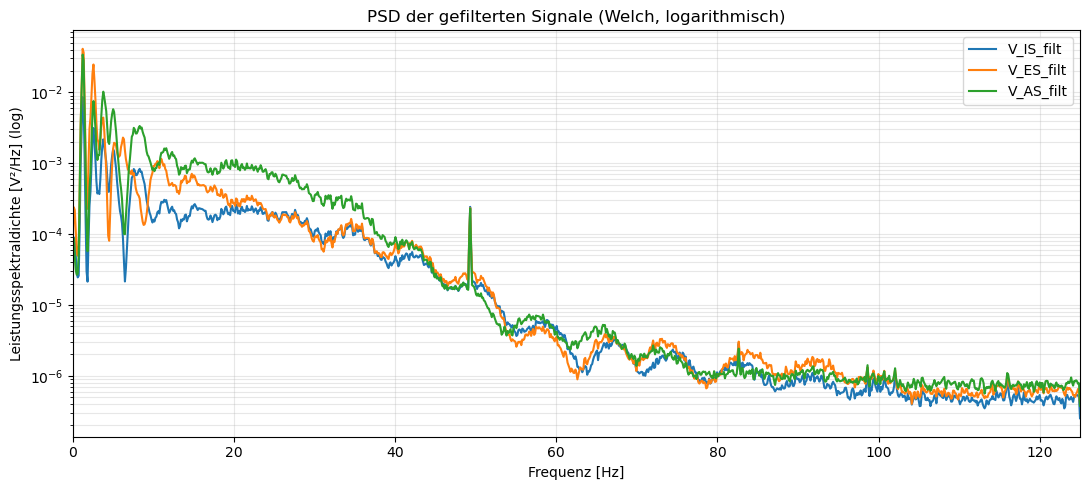

In [4]:
import matplotlib.pyplot as plt
from scipy.signal import welch

# PSD mit dem Welch-Verfahren berechnen
f, Pxx_IS = welch(V_IS, fs=fs, nperseg=2048)
f, Pxx_ES = welch(V_ES, fs=fs, nperseg=2048)
f, Pxx_AS = welch(V_AS, fs=fs, nperseg=2048)

plt.figure(figsize=(11,5))
plt.semilogy(f, Pxx_IS, label="V_IS_filt")
plt.semilogy(f, Pxx_ES, label="V_ES_filt")
plt.semilogy(f, Pxx_AS, label="V_AS_filt")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Leistungsspektraldichte [V²/Hz] (log)")
plt.title("PSD der gefilterten Signale (Welch, logarithmisch)")
plt.xlim(0, fs/2)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
from scipy.signal import firwin, filtfilt
import numpy as np

# Parameter
fs = FS                  # Abtastrate
hp_cutoff_freq = 1.5       # Hochpass-Grenzfrequenz
numtaps_hp = 201    #401     # Länge FIR-HP
lp_cutoff_freq = 37      # Tiefpass-Grenzfrequenz
numtaps_lp = 25          # Länge FIR-LP

# FIR-Design
fir_hp = firwin(numtaps_hp, hp_cutoff_freq, pass_zero=False, fs=fs)
fir_lp = firwin(numtaps_lp, lp_cutoff_freq, pass_zero=True, fs=fs)

# Anwendung Hochpass
V_IS_hp = filtfilt(fir_hp, [1], V_IS)
V_ES_hp = filtfilt(fir_hp, [1], V_ES)
V_AS_hp = filtfilt(fir_hp, [1], V_AS)

# Anwendung Tiefpass
V_IS_filt = filtfilt(fir_lp, [1], V_IS_hp)
V_ES_filt = filtfilt(fir_lp, [1], V_ES_hp)
V_AS_filt = filtfilt(fir_lp, [1], V_AS_hp)


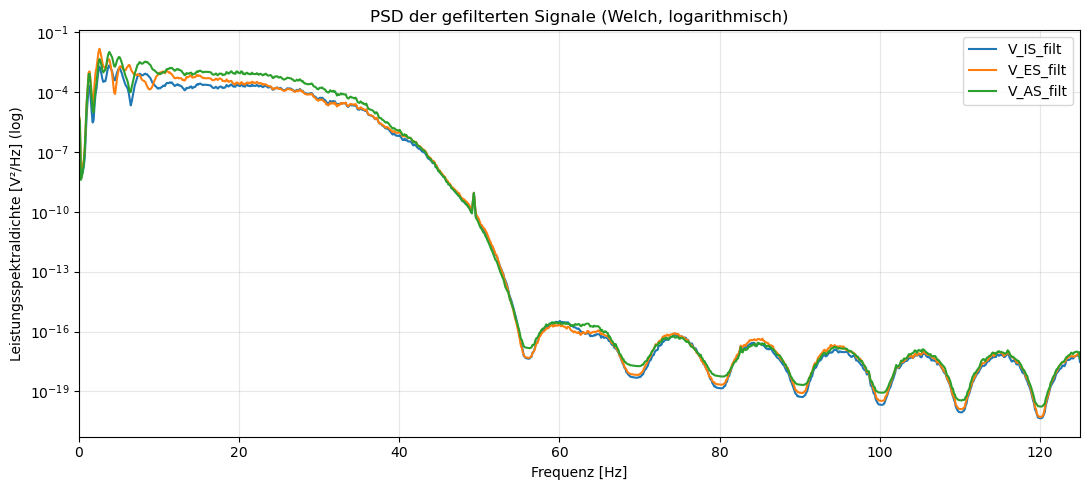

In [6]:
import matplotlib.pyplot as plt
from scipy.signal import welch

# PSD mit dem Welch-Verfahren berechnen
f, Pxx_IS = welch(V_IS_filt, fs=fs, nperseg=2048)
f, Pxx_ES = welch(V_ES_filt, fs=fs, nperseg=2048)
f, Pxx_AS = welch(V_AS_filt, fs=fs, nperseg=2048)

plt.figure(figsize=(11,5))
plt.semilogy(f, Pxx_IS, label="V_IS_filt")
plt.semilogy(f, Pxx_ES, label="V_ES_filt")
plt.semilogy(f, Pxx_AS, label="V_AS_filt")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Leistungsspektraldichte [V²/Hz] (log)")
plt.title("PSD der gefilterten Signale (Welch, logarithmisch)")
plt.xlim(0, fs/2)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# 🧭 Umrechnungsmatrizen
                # ai       ei       si
W = np.array([[ 0.610,  0.171,  0.000], #X
              [ 0.354,  0.000, -1.000], #Y
              [ 0.869,  -0.605, 0.000]])#Z

T = np.array([[ 1.118, 0.000, -0.109],
              [ -0.051, 0.933, -0.087   ],
              [-1.108, 0.000, 0.772]])

D = np.array([[ 0.156,-0.01 ,-0.147],
              [ 0.058, 0.06 ,-0.022],
              [-0.102, 0.065, 0.059],
              [-0.088, 0.108, 0.022],
              [-0.019, 0.106,-0.041],
              [ 0.061, 0.097,-0.063],
              [ 0.128, 0.074,-0.129],
              [ 0.128, 0.022,-0.159]])

In [8]:
#  Transformationsfunktion
def eis_to_frank_xyz(v_is, v_es, v_as):
    ei = v_es - v_is #M-R
    ai = v_as - v_is #L-R
    si = -v_is #-R
    xp, yp, zp = (W @ np.vstack((ai, ei, si)))
    return T @ np.vstack((xp, yp, zp))  # → X, Y, Z

# Anwendung auf unser Fenster
X, Y, Z = eis_to_frank_xyz(V_IS_filt, V_ES_filt, V_AS_filt)



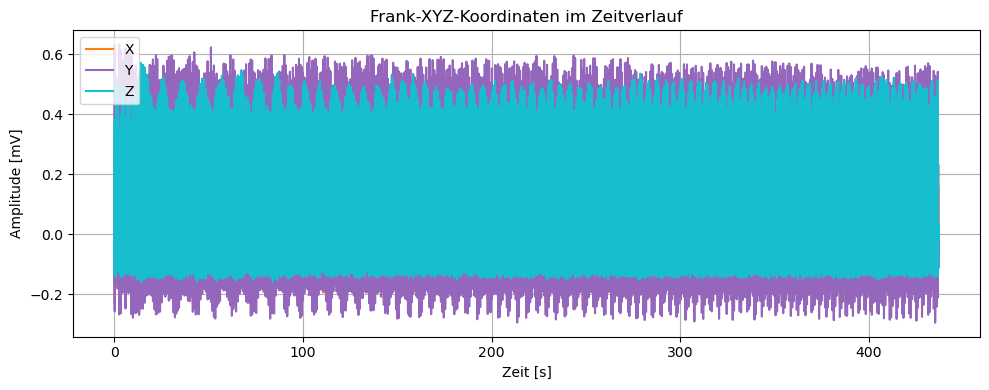

In [9]:
# Plot der XYZ-Kanäle
plt.figure(figsize=(10, 4))
plt.plot(t, X, label="X", color='tab:orange')
plt.plot(t, Y, label="Y", color='tab:purple')
plt.plot(t, Z, label="Z", color='tab:cyan')
plt.title("Frank-XYZ-Koordinaten im Zeitverlauf")
#plt.xlim(6,8)
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude [mV]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Voraussetzung: X, Y, Z sind 1D-Arrays gleicher Länge, t ist in Sekunden (FS bekannt)
df_analysis = pd.DataFrame({
    "Time": t,
    "X": X,
    "Y": Y,
    "Z": Z
})

In [11]:
# ------------------------------------------------------------------
# 12-Lead-Rekonstruktion
# ------------------------------------------------------------------
# Dower-Matrix liefert nur I, II, V1–V6  →
# die übrigen Limb-Leads werden daraus abgeleitet
XYZ = np.vstack((X, Y, Z))            # shape (3, N)
I_II_V = D @ XYZ               # shape (8, N)

leadI   = I_II_V[0]
leadII  = I_II_V[1]
V1, V2, V3, V4, V5, V6 = I_II_V[2:]

# Abgeleitete Limb-Leads
leadIII = leadII - leadI
aVR = -(leadI + leadII) / 2
aVL =  leadI - leadII/2
aVF =  leadII - leadI/2

# Alles in Liste (Reihenfolge Standardausdruck)
leads3 = [leadI, leadII, leadIII]

leads12 = [leadI, leadII, leadIII, aVR, aVL, aVF,
           V1, V2, V3, V4, V5, V6]
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

print("✅ 12-Kanal-EKG rekonstruiert")

✅ 12-Kanal-EKG rekonstruiert


In [12]:
import numpy as np

# Zeitabstand berechnen (angenommen gleichmäßig)
dt = np.mean(np.diff(df_analysis["Time"]))

# Geschwindigkeit = erste Ableitung der Position
df_analysis["V_X"] = np.gradient(df_analysis["X"], dt)
df_analysis["V_Y"] = np.gradient(df_analysis["Y"], dt)
df_analysis["V_Z"] = np.gradient(df_analysis["Z"], dt)

# Betrag der Geschwindigkeit
df_analysis["V_abs"] = np.sqrt(df_analysis["V_X"]**2 + df_analysis["V_Y"]**2 + df_analysis["V_Z"]**2)

# Geschwindigkeit
V_X = np.gradient(df_analysis["X"], dt)
V_Y = np.gradient(df_analysis["Y"], dt)
V_Z = np.gradient(df_analysis["Z"], dt)
V_abs = np.sqrt(V_X**2 + V_Y**2 + V_Z**2)

# Beschleunigung
A_X = np.gradient(V_X, dt)
A_Y = np.gradient(V_Y, dt)
A_Z = np.gradient(V_Z, dt)
A_abs = np.sqrt(A_X**2 + A_Y**2 + A_Z**2)

# Jerk (dritte Ableitung)
J_X = np.gradient(A_X, dt)
J_Y = np.gradient(A_Y, dt)
J_Z = np.gradient(A_Z, dt)

# Krümmung
v = np.stack([V_X, V_Y, V_Z], axis=-1)
a = np.stack([A_X, A_Y, A_Z], axis=-1)
cross_va = np.cross(v, a)
cross_va_norm = np.linalg.norm(cross_va, axis=-1)
v_norm = np.linalg.norm(v, axis=-1)
curvature = cross_va_norm / (v_norm**3 + 1e-15)

# Torsion
j = np.stack([J_X, J_Y, J_Z], axis=-1)
numerator = np.einsum('ij,ij->i', np.cross(v, a), j)
denominator = (cross_va_norm**2 + 1e-15)
torsion = numerator / denominator


# Summensignal berechnen
df_analysis["V_signed_sum"] = df_analysis["V_X"] + df_analysis["V_Y"] + df_analysis["V_Z"]

# Variable aus DataFrame holen
V_signed_sum = df_analysis["V_signed_sum"].values  # oder .to_numpy()

# Ableitung berechnen
dV_signed_sum_dt = np.gradient(V_signed_sum, dt)

# Optional in DataFrame speichern
df_analysis["dV_signed_sum_dt"] = dV_signed_sum_dt

df_analysis["V_X"] = V_X
df_analysis["V_Y"] = V_Y
df_analysis["V_Z"] = V_Z
df_analysis["V_abs"] = V_abs
df_analysis["A_X"] = A_X
df_analysis["A_Y"] = A_Y
df_analysis["A_Z"] = A_Z
df_analysis["A_abs"] = A_abs

df_analysis["Curvature"] = curvature
df_analysis["Torsion"] = torsion


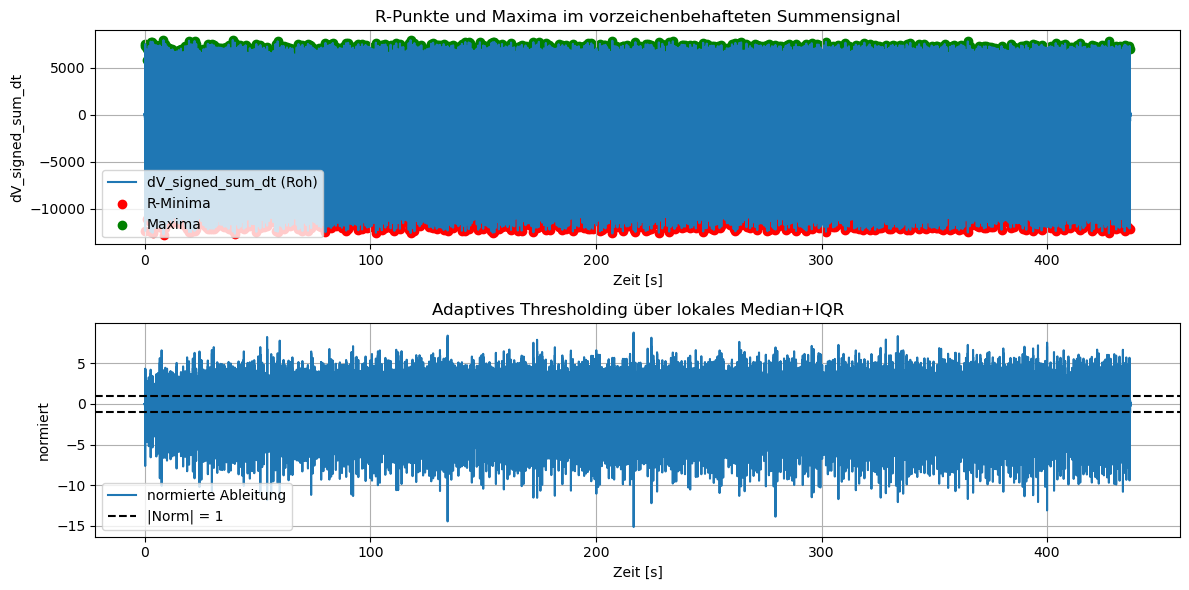

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# df_analysis: DataFrame mit Spalten "Time" und "dV_signed_sum_dt"
times = df_analysis["Time"].values
deriv = df_analysis["dV_signed_sum_dt"].values
N = len(deriv)

# -------------------------------------------
# Parameter
# -------------------------------------------
fs = 250.0                          # Samplingrate [Hz] anpassen
w_long_sec = 0.4                    # Fenster für lokale Median/IQR (z.B. 400 ms)
w_long = max(5, int(w_long_sec * fs))

a = 5.2
eps = 1e-6

# -------------------------------------------
# Lokales adaptives Thresholding (1 Schwellwertband)
# -------------------------------------------
s = pd.Series(deriv)

# lokaler Median
local_med = s.rolling(w_long, center=True, min_periods=1).median()

# lokaler IQR
q75 = s.rolling(w_long, center=True, min_periods=1).quantile(0.75)
q25 = s.rolling(w_long, center=True, min_periods=1).quantile(0.25)
iqr = (q75 - q25).to_numpy()

# adaptiver Schwellwert (Skalenfaktor)
Th = a * iqr + eps

# normierte Ableitung
deriv_norm = (deriv - local_med.to_numpy()) / Th

# -------------------------------------------
# Peak-Detektion wie bisher (Minima/Maxima),
# aber Entscheidung basiert auf deriv_norm
# -------------------------------------------
min_peaks, _ = find_peaks(-deriv)   # Indizes lokaler Minima im Roh-deriv
max_peaks, _ = find_peaks(deriv)    # Indizes lokaler Maxima im Roh-deriv

robust_minima = []
robust_maxima = []

for m in min_peaks:
    left_max = max_peaks[max_peaks < m]
    right_max = max_peaks[max_peaks > m]
    if len(left_max) == 0 or len(right_max) == 0:
        continue

    prev_max = left_max[-1]
    next_max = right_max[0]

    # Bedingung: Minimum stark negativ, flankierende Maxima stark positiv
    if (deriv_norm[m] < -1.0 and
        deriv_norm[prev_max] > 1.0 and
        deriv_norm[next_max] > 1.0):
        robust_minima.append(m)
        robust_maxima.extend([prev_max, next_max])

robust_maxima = sorted(list(set(robust_maxima)))

R = robust_minima

valid_R = [r for r in R if r is not None]
valid_robust_max = [m for m in robust_maxima if m is not None]

# -------------------------------------------
# Plot 1: Roh-Ableitung + R-Punkte + Maxima
# -------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(times, deriv, label="dV_signed_sum_dt (Roh)")
plt.scatter(times[valid_R], deriv[valid_R], color='red', label='R-Minima')
plt.scatter(times[valid_robust_max], deriv[valid_robust_max], color='green', label='Maxima')

plt.xlabel('Zeit [s]')

plt.ylabel('dV_signed_sum_dt')
plt.title('R-Punkte und Maxima im vorzeichenbehafteten Summensignal')
plt.legend()
plt.grid(True)

# -------------------------------------------
# Plot 2: normierte Ableitung + ±1 Linien
# (implizite adaptive Schwelle)
# -------------------------------------------
plt.subplot(2, 1, 2)
plt.plot(times, deriv_norm, label='normierte Ableitung')
plt.axhline(1.0, color='k', linestyle='--', label='|Norm| = 1')
plt.axhline(-1.0, color='k', linestyle='--')
plt.xlabel('Zeit [s]')

plt.ylabel('normiert')
plt.title('Adaptives Thresholding über lokales Median+IQR')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------
# R-Marker im DataFrame speichern
# -------------------------------------------
df_analysis['R'] = 0
df_analysis.loc[robust_minima, 'R'] = 1


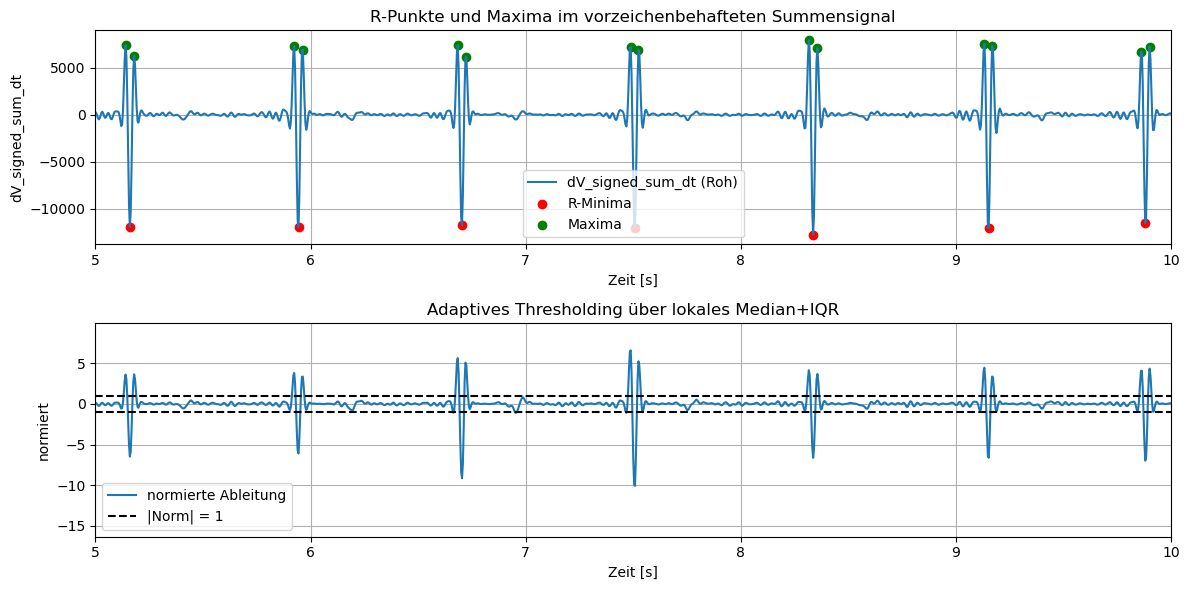

In [14]:
# -------------------------------------------
# Plot 1: Roh-Ableitung + R-Punkte + Maxima
# -------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(times, deriv, label="dV_signed_sum_dt (Roh)")
plt.scatter(times[valid_R], deriv[valid_R], color='red', label='R-Minima')
plt.scatter(times[valid_robust_max], deriv[valid_robust_max], color='green', label='Maxima')

plt.xlabel('Zeit [s]')
plt.xlim(5,10)
plt.ylabel('dV_signed_sum_dt')
plt.title('R-Punkte und Maxima im vorzeichenbehafteten Summensignal')
plt.legend()
plt.grid(True)

# -------------------------------------------
# Plot 2: normierte Ableitung + ±1 Linien
# (implizite adaptive Schwelle)
# -------------------------------------------
plt.subplot(2, 1, 2)
plt.plot(times, deriv_norm, label='normierte Ableitung')
plt.axhline(1.0, color='k', linestyle='--', label='|Norm| = 1')
plt.axhline(-1.0, color='k', linestyle='--')
plt.xlabel('Zeit [s]')
plt.xlim(5,10)
plt.ylabel('normiert')
plt.title('Adaptives Thresholding über lokales Median+IQR')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

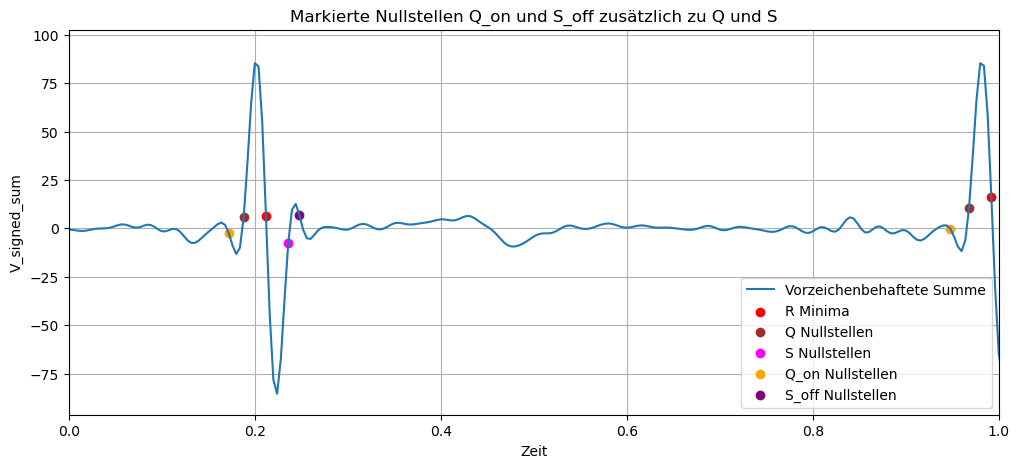

In [15]:
times = df_analysis["Time"].values
sig_sum = df_analysis["V_signed_sum"].values

def find_next_zero_crossing(data, start_idx):
    for i in range(start_idx, len(data) - 1):
        if data[i] == 0 or (data[i] * data[i + 1] < 0):
            return i
    return None

def find_prev_zero_crossing(data, start_idx):
    for i in range(start_idx, 0, -1):
        if data[i] == 0 or (data[i] * data[i - 1] < 0):
            return i
    return None

# Q und S wie gehabt
Q = []
for r_idx in R:
    left_maxes = [mx for mx in robust_maxima if mx < r_idx]
    if len(left_maxes) == 0:
        Q.append(None)
        continue
    max_before = max(left_maxes)
    zero_q = find_prev_zero_crossing(sig_sum, max_before)
    Q.append(zero_q)

S = []
for r_idx in R:
    right_maxes = [mx for mx in robust_maxima if mx > r_idx]
    if len(right_maxes) == 0:
        S.append(None)
        continue
    max_after = min(right_maxes)
    zero_s = find_next_zero_crossing(sig_sum, max_after)
    S.append(zero_s)

# Verschieben der Startindizes für die Suche um eine Position mehr

Q_on = []
for q in Q:
    if q is None or q <= 1:
        Q_on.append(None)
    else:
        # Suche eine Nullstelle vor der bereits gefundenen Nullstelle q
        q_on = find_prev_zero_crossing(sig_sum, q - 1)
        Q_on.append(q_on)

S_off = []
for s in S:
    if s is None or s >= len(sig_sum) - 2:
        S_off.append(None)
    else:
        # Suche eine Nullstelle nach der bereits gefundenen Nullstelle s
        s_off = find_next_zero_crossing(sig_sum, s + 1)
        S_off.append(s_off)


# Filter None
valid_R = [r for r in R if r is not None]
valid_Q = [q for q in Q if q is not None]
valid_S = [s for s in S if s is not None]
valid_Q_on = [qon for qon in Q_on if qon is not None]
valid_S_off = [soff for soff in S_off if soff is not None]


# Zeitbereich für die Analyse definieren
time_start = 0    # Beispielstartzeit
time_end = 1     # Beispielendzeit

plt.figure(figsize=(12,5))
plt.plot(times, sig_sum, label="Vorzeichenbehaftete Summe")
plt.scatter(times[valid_R], sig_sum[valid_R], c='red', label="R Minima")
plt.scatter(times[valid_Q], sig_sum[valid_Q], c='brown', label="Q Nullstellen")
plt.scatter(times[valid_S], sig_sum[valid_S], c='magenta', label="S Nullstellen")
plt.scatter(times[valid_Q_on], sig_sum[valid_Q_on], c='orange', label="Q_on Nullstellen")
plt.scatter(times[valid_S_off], sig_sum[valid_S_off], c='purple', label="S_off Nullstellen")


plt.xlabel('Zeit')
plt.ylabel('V_signed_sum')
plt.xlim(time_start, time_end)
plt.title('Markierte Nullstellen Q_on und S_off zusätzlich zu Q und S')
plt.legend()
plt.grid(True)
plt.show()


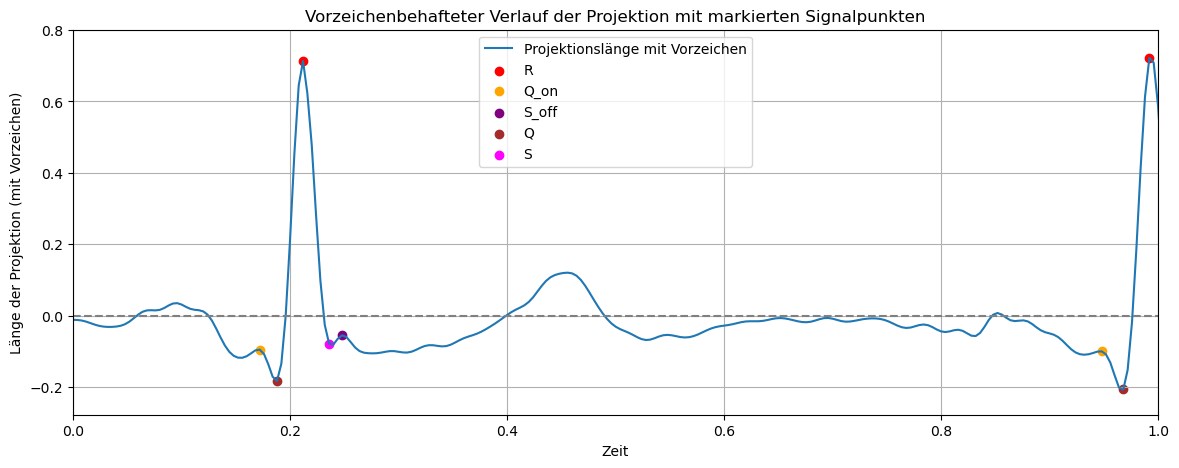

In [16]:
import numpy as np
import matplotlib.pyplot as plt

vector_lengths_signed = np.zeros(len(df_analysis))
r_indices = R + [len(df_analysis)]  # Sichere letzte Intervall

start_idx = 0  # Ursprung ist (0,0,0)

origin = np.array([0, 0, 0])  # Neuer Ursprung

for i, r_idx in enumerate(R):
    end_idx = r_indices[i]
    if start_idx > end_idx:
        continue

    # Referenzvektor vom Ursprung zum R-Punkt
    v_ref = df_analysis.loc[r_idx, ['X', 'Y', 'Z']].values - origin
    v_ref_norm = v_ref / np.linalg.norm(v_ref)

    # Trajektoriepunkte vom Start bis zum R-Punkt
    idx_range = range(start_idx, end_idx + 1)
    traj_points = df_analysis.loc[idx_range, ['X', 'Y', 'Z']].values

    # Vektoren vom Ursprung zum Trajektoriepunkt
    vectors = traj_points - origin

    # Projektion mit Vorzeichen
    projections = np.dot(vectors, v_ref_norm)

    # Speichere in Gesamtarray
    for idx, val in zip(idx_range, projections):
        vector_lengths_signed[idx] = val

    # Update Start für nächsten Zyklus
    start_idx = end_idx + 1

df_analysis['vector_lengths_signed'] = vector_lengths_signed




plt.figure(figsize=(14, 5))
plt.plot(df_analysis['Time'], df_analysis['vector_lengths_signed'], label='Projektionslänge mit Vorzeichen')
plt.axhline(0, color='gray', linestyle='--')

# Markiere R-Punkte im Zeitverlauf
valid_R = [r for r in R if r is not None]
plt.scatter(df_analysis.loc[valid_R, 'Time'], df_analysis.loc[valid_R, 'vector_lengths_signed'], color='red', label='R')

# Markiere Q_on Punkte (vormals R_on)
valid_Q_on = [qon for qon in Q_on if qon is not None]
plt.scatter(df_analysis.loc[valid_Q_on, 'Time'], df_analysis.loc[valid_Q_on, 'vector_lengths_signed'], color='orange', label='Q_on')

# Markiere S_off Punkte (vormals R_off)
valid_S_off = [soff for soff in S_off if soff is not None]
plt.scatter(df_analysis.loc[valid_S_off, 'Time'], df_analysis.loc[valid_S_off, 'vector_lengths_signed'], color='purple', label='S_off')

# Markiere Nullpunkte vor Q (ehemals Nullpunkt vor R_on)
valid_Q = [q for q in Q if q is not None]
plt.scatter(df_analysis.loc[valid_Q, 'Time'], df_analysis.loc[valid_Q, 'vector_lengths_signed'], color='brown', label='Q')

# Markiere Nullpunkte nach S (ehemals Nullpunkt nach R_off)
valid_S = [s for s in S if s is not None]
plt.scatter(df_analysis.loc[valid_S, 'Time'], df_analysis.loc[valid_S, 'vector_lengths_signed'], color='magenta', label='S')

plt.xlabel('Zeit')
plt.ylabel('Länge der Projektion (mit Vorzeichen)')
plt.xlim(time_start, time_end)
plt.title('Vorzeichenbehafteter Verlauf der Projektion mit markierten Signalpunkten')
plt.grid(True)
plt.legend()
plt.show()

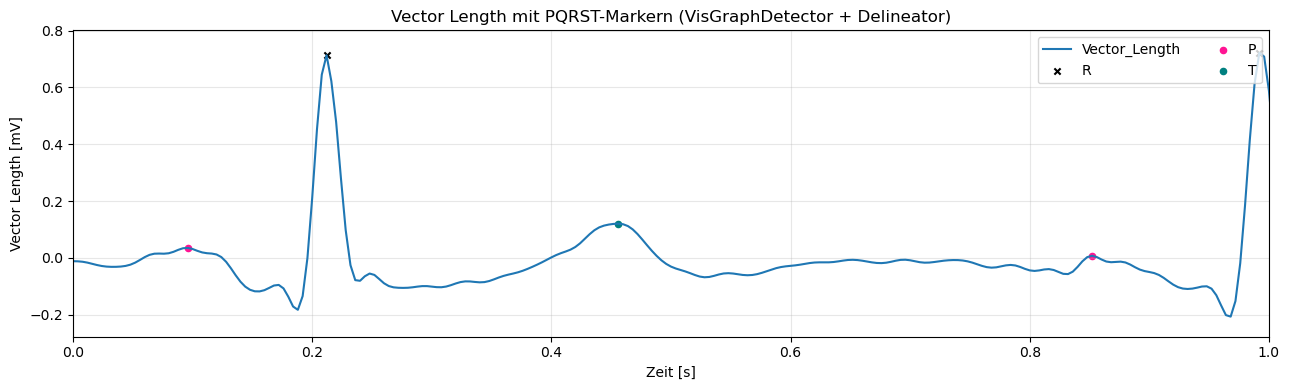

✅ Vector-Length-Annotation: R=551, P=551, T=550


,Time,X,Y,Z,V_X,V_Y,V_Z,V_abs,V_signed_sum,dV_signed_sum_dt,...,mk_R_on,mk_R_off,mk_P,mk_P_on,mk_P_off,mk_T,mk_T_on,mk_T_off,Markers,Segment
0,0.000,0.013896,-0.014682,-0.012387,-1.696919,0.383758,0.617664,1.846162,-0.695497,-30.332324,...,0,0,0,0,0,0,0,0,,Rest
1,0.004,0.007109,-0.013147,-0.009916,-1.419093,0.177872,0.424394,1.491835,-0.816826,-49.349338,...,0,0,0,0,0,0,0,0,,Rest
2,0.008,0.002544,-0.013259,-0.008992,-0.705247,-0.333791,-0.051254,0.781931,-1.090292,-61.730017,...,0,0,0,0,0,0,0,0,,Rest
3,0.012,0.001467,-0.015817,-0.010326,0.148005,-0.896450,-0.562222,1.068467,-1.310666,-26.748781,...,0,0,0,0,0,0,0,0,,Rest
4,0.016,0.003728,-0.020430,-0.013490,0.813814,-1.251769,-0.866327,1.726193,-1.304282,33.405387,...,0,0,0,0,0,0,0,0,,Rest


In [17]:
# === 0) Imports ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vg_detector import VisGraphDetector
from prominence_delineator import ProminenceDelineator

# Für Delineator wird ein "multilead"-Format erwartet -> 1 Lead = Vector_Length
sig_multilead = [vector_lengths_signed]
rpeaks_multilead = [list(R)]



# === 3) PQRST-Delineation auf Vector_Length ===============
delineator = ProminenceDelineator(
    sampling_frequency=FS,
    max_qrs_interval=0.26,
    max_r_rise_time=0.15,
    typical_st_segment=0.18,
    max_pr_interval=0.3
)

waves = delineator.find_waves_multilead(
    sig_multilead=sig_multilead,
    rpeaks_multilead=rpeaks_multilead,
    multilead_correction=True,
    include_nodetections=False
)

# Zugriff für unseren (einzigen) Lead
lead_idx = 0
def safe_get(wave):
    arr = waves.get(wave, [])
    if len(arr) > lead_idx:
        return np.asarray(arr[lead_idx], dtype=int)
    return np.array([], dtype=int)

R      = safe_get("R")
Q      = safe_get("Q")
S      = safe_get("S")
R_on   = safe_get("R_on")
R_off  = safe_get("R_off")
P      = safe_get("P")
P_on   = safe_get("P_on")
P_off  = safe_get("P_off")
T      = safe_get("T")
T_on   = safe_get("T_on")
T_off  = safe_get("T_off")

# === 4) Marker ins DataFrame schreiben =====================
# a) Diskrete Marker-Spalten (0/1) pro Event
for name, idxs in {
    "mk_R": R, "mk_Q": Q, "mk_S": S,
    "mk_R_on": R_on, "mk_R_off": R_off,
    "mk_P": P, "mk_P_on": P_on, "mk_P_off": P_off,
    "mk_T": T, "mk_T_on": T_on, "mk_T_off": T_off
}.items():
    df_analysis[name] = 0
    valid = idxs[(idxs >= 0) & (idxs < len(df_analysis))]
    df_analysis.loc[valid, name] = 1

# b) Kompakte Marker-Zeile (String) – falls du gern „R|Q|T_on“ o. ä. pro Sample sehen willst
all_mark_cols = ["mk_R","mk_Q","mk_S","mk_R_on","mk_R_off","mk_P","mk_P_on","mk_P_off","mk_T","mk_T_on","mk_T_off"]
pretty_names  = ["R","Q","S","R_on","R_off","P","P_on","P_off","T","T_on","T_off"]

def row_marker_str(row):
    labs = [nm for nm_col, nm in zip(all_mark_cols, pretty_names) if row[nm_col] == 1]
    return "|".join(labs) if labs else ""

df_analysis["Markers"] = df_analysis[all_mark_cols].apply(row_marker_str, axis=1)

# c) Segment-Label (P / QRS / T / Rest) aus On-/Off-Sets
segment = np.full(len(df_analysis), "Rest", dtype=object)
def fill_mask(on_idx, off_idx, label):
    n = len(segment)
    n_pairs = min(len(on_idx), len(off_idx))
    for s, e in zip(on_idx[:n_pairs], off_idx[:n_pairs]):
        if 0 <= s < e <= n:
            segment[s:e] = label

fill_mask(P_on,  P_off,  "P")
fill_mask(R_on,  R_off,  "QRS")
fill_mask(T_on,  T_off,  "T")
df_analysis["Segment"] = segment

# === 5) Plausibilitäts-Plot: Vector_Length + Marker ========
plt.figure(figsize=(13, 4))
plt.plot(df_analysis["Time"], df_analysis['vector_lengths_signed'], label="Vector_Length")
if len(R):
    plt.scatter(df_analysis["Time"].iloc[R], df_analysis['vector_lengths_signed'].iloc[R],
                c="k", marker="x", s=20, label="R")
if len(P):
    plt.scatter(df_analysis["Time"].iloc[P], df_analysis['vector_lengths_signed'].iloc[P],
                c="deeppink", s=20, label="P")
if len(T):
    plt.scatter(df_analysis["Time"].iloc[T], df_analysis['vector_lengths_signed'].iloc[T],
                c="teal", s=20, label="T")
plt.xlabel("Zeit [s]"); plt.ylabel("Vector Length [mV]")
plt.xlim(time_start, time_end)
plt.title("Vector Length mit PQRST-Markern (VisGraphDetector + Delineator)")
plt.grid(True, alpha=0.3); plt.legend(loc="upper right", ncol=2)
plt.tight_layout(); plt.show()

print(f"✅ Vector-Length-Annotation: R={len(R)}, P={len(P)}, T={len(T)}")
display(df_analysis.head())

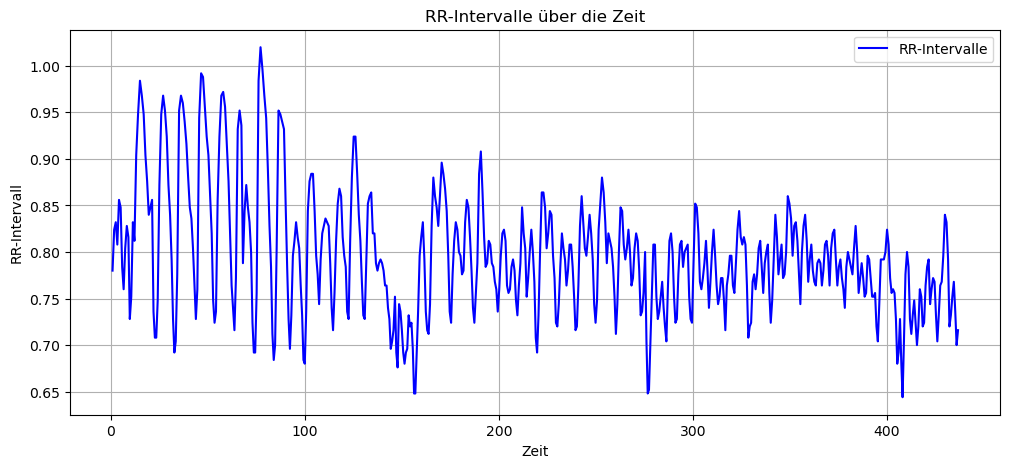

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# R ist robust_minima (bereits gefiltert auf gültige Indizes)
# Zeitpunkte der R-Zacken
times_R = df_analysis.loc[R, 'Time'].values

# Werte der Projektion an R-Zeitpunkten
proj_at_R = df_analysis.loc[R, 'vector_lengths_signed'].values

# RR-Intervalle (Differenzen der Time-Werte)
RR_intervals = np.diff(times_R)

# Amplitudenänderungen der Projektion (Differenzen)
amplitude_changes = np.diff(proj_at_R)

# Ergebnisse in neuem DataFrame abspeichern
df_results = pd.DataFrame({
    'Time': times_R[1:],  # Zeit passend zu den Intervallen
    'RR_intervals': RR_intervals,
    'amplitude_changes': amplitude_changes,
})

# Plots
plt.figure(figsize=(12, 5))
plt.plot(df_results['Time'], df_results['RR_intervals'], color='blue', label='RR-Intervalle')
plt.xlabel('Zeit')
plt.ylabel('RR-Intervall')
plt.title('RR-Intervalle über die Zeit')
plt.grid(True)
plt.legend()
plt.show()


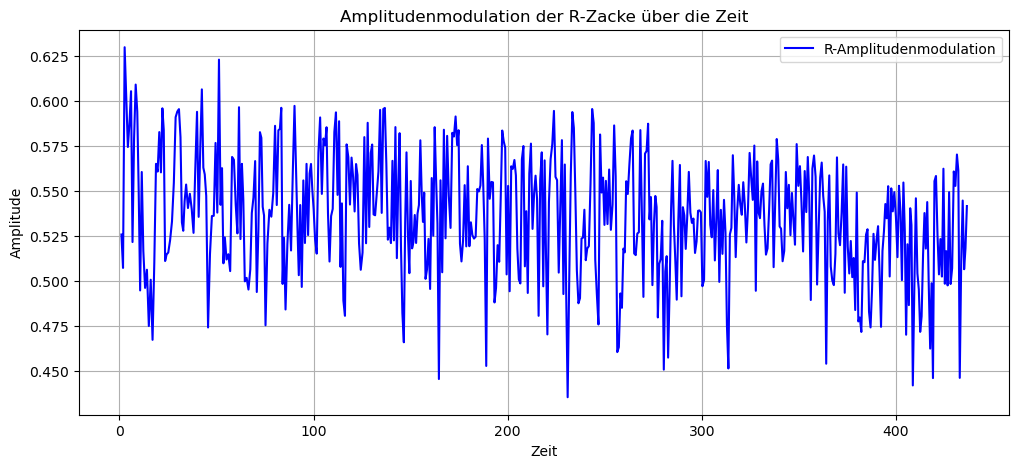

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# R ist robust_minima (gültige Indizes der R-Zacken)

# Zeitpunkte und Amplituden der R-Zacken
times_R = df_analysis.loc[R, 'Time'].to_numpy()
amp_R   = df_analysis.loc[R, 'Y'].to_numpy()

# vollständiges Zeitraster aus dem DataFrame
t_full = df_analysis['Time'].to_numpy()

# lineare Interpolation der R-Amplituden auf das gesamte Zeitraster
amp_full = np.interp(t_full, times_R, amp_R)

# neues Signal im selben DataFrame speichern
df_analysis['1D_R_Amplitude'] = amp_full

df_results['1D_R_Amplitude'] = np.interp(df_results['Time'].to_numpy(),
                                         times_R, amp_R)

# Plot aus df_analysis
plt.figure(figsize=(12, 5))
plt.plot(df_results['Time'], df_results['1D_R_Amplitude'],
         color='blue', label='R-Amplitudenmodulation')
plt.xlabel('Zeit')
plt.ylabel('Amplitude')
plt.title('Amplitudenmodulation der R-Zacke über die Zeit')
plt.grid(True)
plt.legend()
plt.show()


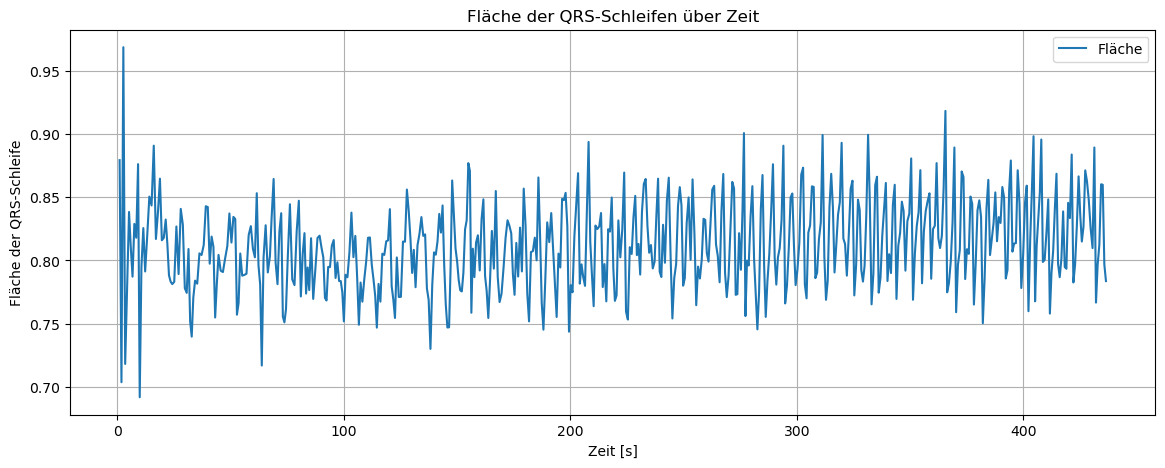

In [20]:
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

# Funktion zur Berechnung von Fläche (Area) und Mittel-Normalenvektor (Normal) der Schleifen zwischen R-Punkten
def get_loop_area_and_normal(df, R):
    areas = []
    normals = []
    
    for i in range(len(R) - 1):
        idx_start = R[i]
        idx_end = R[i + 1]
        
        # Abfangen von None-Werten (optional, falls vorhanden)
        if idx_start is None or idx_end is None:
            areas.append(np.nan)
            normals.append(np.array([np.nan, np.nan, np.nan]))
            continue
        
        # Teiltrajektorie aus X,Y,Z-Werten
        loop_points = df.loc[idx_start:idx_end, ['X', 'Y', 'Z']].values
        
        if len(loop_points) < 3:
            areas.append(0)
            normals.append(np.array([np.nan, np.nan, np.nan]))
            continue
        
        try:
            hull = ConvexHull(loop_points)
            area = hull.area
            
            # Mittel-Normalenvektor gewichtet über Flächenanteil der Dreiecke
            normals_sum = np.zeros(3)
            for simplex in hull.simplices:
                tri = loop_points[simplex]
                v1 = tri[1] - tri[0]
                v2 = tri[2] - tri[0]
                normal = np.cross(v1, v2)
                tri_area = np.linalg.norm(normal) / 2
                if tri_area > 0:
                    normal_unit = normal / (2 * tri_area)
                    normals_sum += normal_unit * tri_area
            
            norm = np.linalg.norm(normals_sum)
            if norm > 0:
                normal_mean = normals_sum / norm
            else:
                normal_mean = np.array([np.nan, np.nan, np.nan])
        
        except:
            area = 0
            normal_mean = np.array([np.nan, np.nan, np.nan])
        
        areas.append(area)
        normals.append(normal_mean)
    
    return areas, normals

# Beispiel: df_results existiert bereits mit 'Time', 'RR_intervals', 'amplitude_changes'
# R ist robust_minima (indizes der R-Punkte im df_analysis)

# Berechnung der Areas und Normalenvektoren
areas, normals = get_loop_area_and_normal(df_analysis, R)

# Winkel der Normalenvektoren relativ zum Vektor [0,0,1]
unit_vector = np.array([0, 0, 1])
angles = []
for n in normals:
    if np.any(np.isnan(n)):
        angles.append(np.nan)
    else:
        n_norm = n / np.linalg.norm(n)
        cos_angle = np.clip(np.dot(n_norm, unit_vector), -1.0, 1.0)
        angle = np.arccos(cos_angle) * (180 / np.pi)
        angles.append(angle)
angles = np.array(angles)

# Füge die neuen Spalten zu df_results hinzu
assert len(df_results) == len(R) - 1, "Länge von df_results muss len(R)-1 sein"
df_results['Area'] = areas
df_results['Normal_Angle'] = angles

# Plot Fläche der Schleifen über Zeit
plt.figure(figsize=(14, 5))
plt.plot(df_results['Time'], df_results['Area'], color='tab:blue', label='Fläche')
plt.xlabel('Zeit [s]')
plt.ylabel('Fläche der QRS-Schleife')
plt.title('Fläche der QRS-Schleifen über Zeit')
plt.grid(True)
plt.legend()
plt.show()


In [21]:
import numpy as np
import pandas as pd

# Deine Daten (Beispiel)
x_r_full = df_analysis.loc[R, 'X'].values
y_r_full = df_analysis.loc[R, 'Y'].values
z_r_full = df_analysis.loc[R, 'Z'].values
Time_full = df_analysis.loc[R, 'Time'].values

# Ab dem zweiten R-Punkt (Index 1...)
x_r = x_r_full[1:]
y_r = y_r_full[1:]
z_r = z_r_full[1:]
Time = Time_full[1:]

# 1. Kugelkoordinaten ab zweitem R-Punkt
r = np.sqrt(x_r**2 + y_r**2 + z_r**2)
theta = np.arctan2(y_r, x_r)
phi = np.arccos(z_r / (r + 1e-10))


# Daten einfügen
df_results['r'] = r
df_results['phi'] = phi
df_results['theta'] = theta

# 2. Komplexes Signal (bestehend aus phi als Realteil und theta als Imaginärteil)
complex_signal = df_results['phi'] + 1j * df_results['theta']

# Betrag
amplitude = np.abs(complex_signal)

# Winkel (Phase), im Bereich [-pi, pi]
angle = np.angle(complex_signal)

# In DataFrame speichern
df_results['angular_complex'] = amplitude
df_results['angular_complex_angle'] = angle



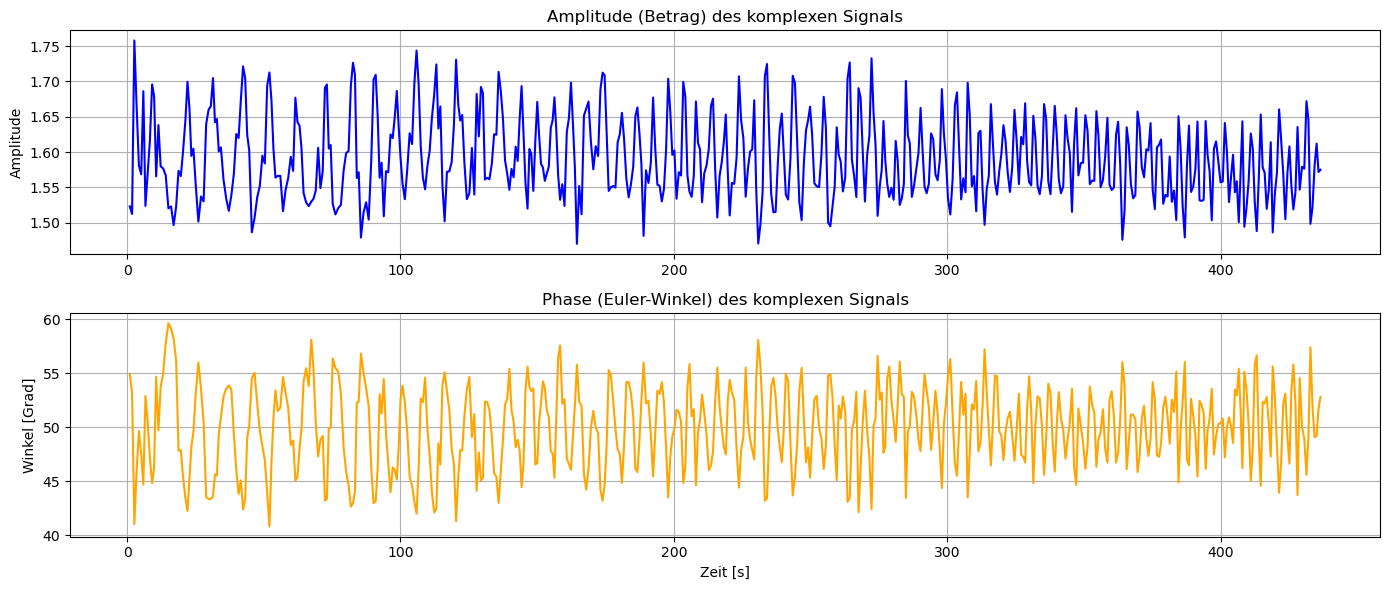

In [22]:
import matplotlib.pyplot as plt
import numpy as np

time = df_results['Time']
amplitude = df_results['angular_complex']
angle = df_results['angular_complex_angle']  # im Bogenmaß

# Alternativ optional Winkel in Grad
angle_deg = np.degrees(angle)

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(time, amplitude, color='blue')
plt.title('Amplitude (Betrag) des komplexen Signals')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time, angle_deg, color='orange')
plt.title('Phase (Euler-Winkel) des komplexen Signals')
plt.ylabel('Winkel [Grad]')
plt.xlabel('Zeit [s]')
plt.grid(True)

plt.tight_layout()
plt.show()


In [23]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def adaptive_mahalanobis_correction(df, feature_cols, time_col='Time',
                                    window_dRR=91, window_mRR=11, a=5.2):
    """
    Adaptive Artefaktkorrektur auf Basis der Mahalanobis-Distanz,
    analog zur dRR- und mRR-Logik (Lipponen & Tarvainen 2019).

    - df:           DataFrame mit Zeitspalte und Feature-Spalten
    - feature_cols: Liste der Spalten, die in X für Mahalanobis eingehen
    - time_col:     Name der Zeitspalte
    - window_dRR:   Fenstergröße für dD (Differenzen der Distanz)
    - window_mRR:   Fenstergröße für mD (Abweichung vom lokalen Median der Distanz)
    - a:            Multiplikator für adaptive Schwellenwerte

    Rückgabe:
    - df_cleaned:      bereinigter DataFrame
    - distances:       Mahalanobis-Distanz
    - dD_norm:         normierte Distanz-Differenzen
    - mD_norm:         normierte Median-Abweichungen der Distanz
    - Th1:             adaptiver Schwellwert für dD
    - Th2:             adaptiver Schwellwert für mD
    - artifact_mask:   bool-Array der Artefakte
    """
    # 1) Feature-Matrix X und Zeitvektor
    X = df[feature_cols].values
    t = df[time_col].values
    N = len(df)

    # 2) Mahalanobis-Distanz
    mean_vec = np.mean(X, axis=0)
    cov_mat = np.cov(X, rowvar=False)
    inv_cov_mat = np.linalg.inv(cov_mat)

    def mahalanobis_dist(x, mean_vec, inv_cov_mat):
        diff = x - mean_vec
        return np.sqrt(np.dot(np.dot(diff, inv_cov_mat), diff.T))

    distances = np.array([mahalanobis_dist(x, mean_vec, inv_cov_mat) for x in X])

    # Hilfsfunktionen wie in deinem RR-Skript
    def local_iqd(x, w):
        iqds = np.zeros_like(x)
        half_w = w // 2
        for i in range(len(x)):
            start = max(0, i - half_w)
            end = min(len(x), i + half_w + 1)
            iqd = np.subtract(*np.percentile(x[start:end], [75, 25]))
            iqds[i] = iqd
        return iqds

    def local_median_diff(z, w):
        med_diff = np.zeros_like(z)
        half_w = w // 2
        for i in range(len(z)):
            start = max(0, i - half_w)
            end = min(len(z), i + half_w + 1)
            local_med = np.median(z[start:end])
            med_diff[i] = z[i] - local_med
        return med_diff

    # 3) dD (Differenzen der Distanz) und adaptiver Th1
    dD = np.diff(distances, prepend=distances[0])
    qd_dD = local_iqd(dD, window_dRR)
    Th1 = a * qd_dD + 1e-6
    dD_norm = dD / Th1

    # 4) mD (Abweichung vom lokalen Median der Distanz) und adaptiver Th2
    mD = local_median_diff(distances, window_mRR)
    qd_mD = local_iqd(mD, window_mRR)
    Th2 = a * qd_mD + 1e-6
    mD_norm = mD / Th2

    # 5) Artefaktmaske: analog zu dRR_norm / mRR_norm
    artifact_mask = (np.abs(dD_norm) > 1) | (np.abs(mD_norm) > 1)

    # 6) Interpolation über Artefakte in allen Feature-Spalten
    good_idx = np.where(~artifact_mask)[0]
    if len(good_idx) < 2:
        print("Zu wenige saubere Punkte zur Interpolation")
        return df.copy(), distances, dD_norm, mD_norm, Th1, Th2, artifact_mask

    df_cleaned = df.copy()
    for col in feature_cols:
        z = df[col].values
        interp_func = interp1d(t[good_idx], z[good_idx],
                               kind='linear', fill_value='extrapolate')
        z_corr = z.copy()
        z_corr[artifact_mask] = interp_func(t)[artifact_mask]
        df_cleaned[col] = z_corr

    return df_cleaned, distances, dD_norm, mD_norm, Th1, Th2, artifact_mask


In [24]:
feature_cols = [
    'RR_intervals',
    'Area',
    'r',
    'angular_complex',
    'angular_complex_angle',
    '1D_R_Amplitude'
]

(df_results_clean,
 distances,
 dD_norm,
 mD_norm,
 Th1,
 Th2,
 artifact_mask) = adaptive_mahalanobis_correction(
    df_results,
    feature_cols=feature_cols,
    time_col='Time',
    window_dRR=91,
    window_mRR=11,
    a=5.2
)

print(f"Anzahl adaptiv erkannter Artefakte: {artifact_mask.sum()}")


Anzahl adaptiv erkannter Artefakte: 1


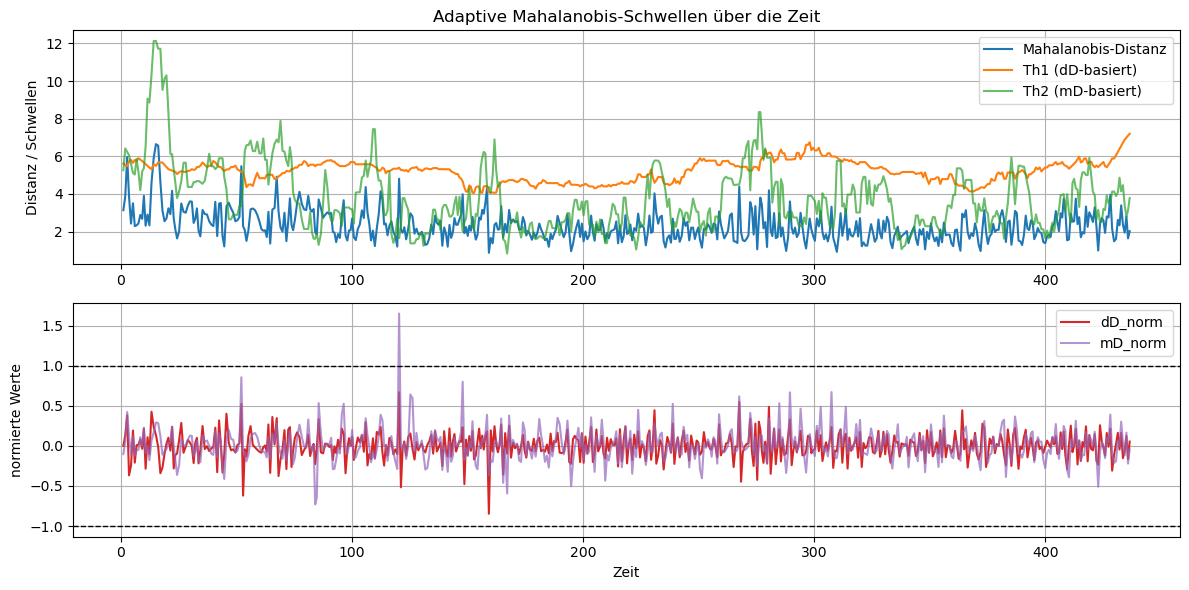

In [25]:
import matplotlib.pyplot as plt
t = df_results['Time'].values

plt.figure(figsize=(12, 6))

# 1) Distanz + ein Schwellenwert (optional beide)
plt.subplot(2, 1, 1)
plt.plot(t, distances, label='Mahalanobis-Distanz', color='C0')
plt.plot(t, Th1, label='Th1 (dD-basiert)', color='C1')
plt.plot(t, Th2, label='Th2 (mD-basiert)', color='C2', alpha=0.7)
plt.ylabel('Distanz / Schwellen')
plt.title('Adaptive Mahalanobis-Schwellen über die Zeit')
plt.grid(True)
plt.legend()

# 2) Normierte Größen mit fester Grenze 1
plt.subplot(2, 1, 2)
plt.plot(t, dD_norm, label='dD_norm', color='C3')
plt.plot(t, mD_norm, label='mD_norm', color='C4', alpha=0.7)
plt.axhline(1, color='k', linestyle='--', linewidth=1)
plt.axhline(-1, color='k', linestyle='--', linewidth=1)
plt.xlabel('Zeit')
plt.ylabel('normierte Werte')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

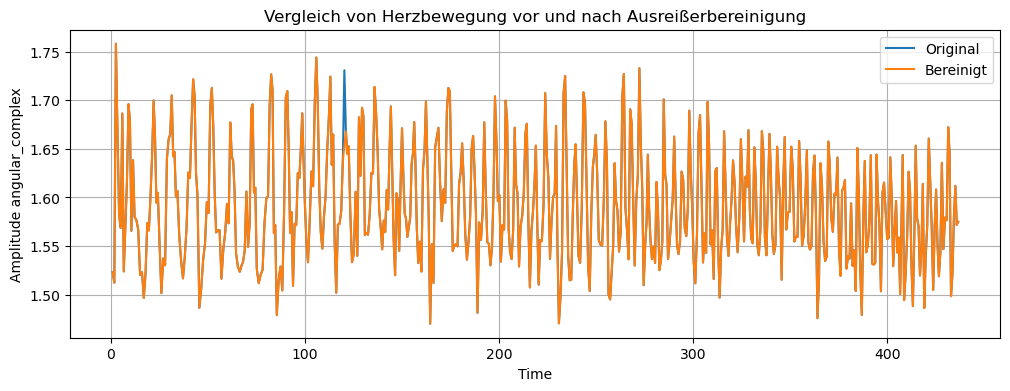

In [26]:
# Optional: Vergleich plotten (hier beispielhaft Amplitude)
plt.figure(figsize=(12, 4))
plt.plot(df_results['Time'], df_results['angular_complex'], label='Original')
plt.plot(df_results_clean['Time'], df_results_clean['angular_complex'], label='Bereinigt')
plt.xlabel('Time')
plt.ylabel('Amplitude angular_complex')
plt.title('Vergleich von Herzbewegung vor und nach Ausreißerbereinigung')
plt.legend()
plt.grid(True)
plt.show()

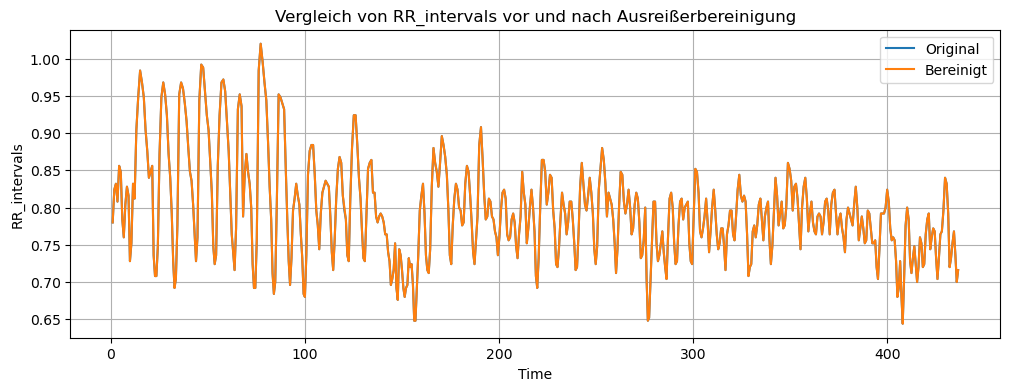

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(df_results['Time'], df_results['RR_intervals'], label='Original')
plt.plot(df_results_clean['Time'], df_results_clean['RR_intervals'], label='Bereinigt')
plt.xlabel('Time')
plt.ylabel('RR_intervals')
plt.title('Vergleich von RR_intervals vor und nach Ausreißerbereinigung')
plt.legend()
plt.grid(True)
plt.show()

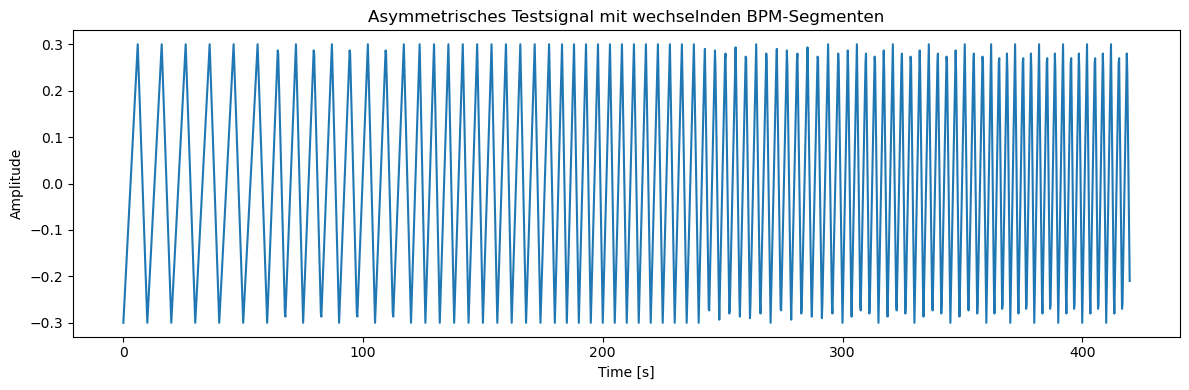

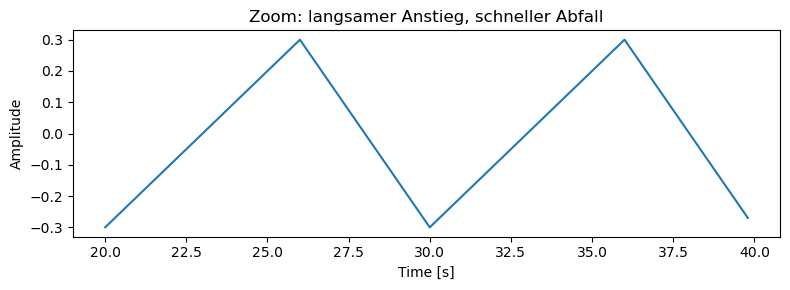

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import sawtooth  # wichtig

Fs = 5.0  # Samplingfrequenz [Hz]
duration_per_segment = 60  # Dauer eines Segments in Sekunden
bpm_list = [6, 8, 10, 12, 14, 16, 18]  # Beats per Minute

t_segments = [np.arange(0, duration_per_segment, 1/Fs) for _ in bpm_list]
signal_segments = []

# Parameter für Asymmetrie
# width = Anteil der Periode, in der die steigende Flanke liegt.
# width > 0.5: langer Anstieg, kurzer Abfall.
width = 0.6
A = 0.3  # Amplitude (an dein Echt-Signal anpassbar)

for bpm in bpm_list:
    freq_hz = bpm / 60.0
    t = np.arange(0, duration_per_segment, 1/Fs)
    phase = 2 * np.pi * freq_hz * t

    # Asymmetrische Sägezahnwelle: langsam hoch, schnell runter
    tri_asym = sawtooth(phase, width=width)     # Bereich [-1, 1]
    tri_asym = tri_asym - np.mean(tri_asym)     # DC-Anteil entfernen
    seg = A * tri_asym

    signal_segments.append(seg)

# Gesamtsignal zusammensetzen
signal = np.concatenate(signal_segments)
t_total = np.arange(0, duration_per_segment * len(bpm_list), 1/Fs)

df_TestSignal = pd.DataFrame({
    "Time": t_total,
    "Sig_Sweep": signal
})

# Plot zur Kontrolle (Zoom auf ein Segment zeigt Form besser)
plt.figure(figsize=(12, 4))
plt.plot(df_TestSignal["Time"], df_TestSignal["Sig_Sweep"])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Asymmetrisches Testsignal mit wechselnden BPM-Segmenten")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
mask_zoom = (df_TestSignal["Time"] >= 20) & (df_TestSignal["Time"] < 40)  # z.B. 2. Segment
plt.plot(df_TestSignal.loc[mask_zoom, "Time"],
         df_TestSignal.loc[mask_zoom, "Sig_Sweep"])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Zoom: langsamer Anstieg, schneller Abfall")
plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter, correlate
from scipy.interpolate import interp1d, PchipInterpolator
import pywt

# =========================================================
# 0) Globale Einstellungen
# =========================================================

Fs_res  = 10.0
freq_min, freq_max = 0.01, 0.445
n_scales = 200
wavelet = 'cmor2.5-1.5'

resp_band_min = 0.05
resp_band_max = 0.50

bpm_sequence = [6, 8, 10, 12, 14, 16, 18]
segment_duration_sec = 60.0
tol_hz = 0.01

results_dir = "/BeyondSingleLeadEDR/results_CSV" #"/YourFolderPath/results_CSV"
plot_dir    = "/BeyondSingleLeadEDR/result_Plots" #"/YourfolderPath/result_Plots"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

eps = 1e-12

# =========================================================
# 0) Compute Scalogram and Ridge
# =========================================================

def compute_scalogram_and_ridge(
    df_results_clean,
    signal_cols,
    time_col="Time",
    Fs_res=Fs_res,
    freq_min=freq_min,
    freq_max=freq_max,
    n_scales=n_scales,
    wavelet=wavelet,
    interpolation_method="pchip",
    plot_scalogram=True,
    subject_id="",
    session_id=""
):
    """
    signal_cols : str oder Liste[str]
      - 1 Spalte  -> normales Scalogramm dieser Komponente
      - >1 Spalten -> Ensemble-Scalogramm = Mittel der normalisierten Powers

    Rückgabe:
      t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax
    """
    if isinstance(signal_cols, str):
        signal_cols = [signal_cols]

    t = np.asarray(df_results_clean[time_col])
    t_uniform = np.arange(t.min(), t.max(), 1/Fs_res)

    def preproc_signal(y):
        if interpolation_method == "pchip":
            interp_func = PchipInterpolator(t, y)
        else:
            interp_func = interp1d(t, y, kind=interpolation_method,
                                   fill_value="extrapolate")
        y_uniform = interp_func(t_uniform)
        wl = min(101, len(y_uniform) if len(y_uniform) % 2 == 1 else len(y_uniform) - 1)
        baseline = savgol_filter(y_uniform, window_length=wl, polyorder=1)
        return y_uniform, y_uniform - baseline

    freqs = np.linspace(freq_min, freq_max, n_scales)
    scales = pywt.scale2frequency(wavelet, freqs) / (1 / Fs_res)

    y_uni_list, y_det_list, power_list = [], [], []
    for col in signal_cols:
        y = np.asarray(df_results_clean[col])
        y_uni, y_det = preproc_signal(y)
        y_uni_list.append(y_uni)
        y_det_list.append(y_det)
        coeffs, _ = pywt.cwt(y_det, scales, wavelet, sampling_period=1/Fs_res)
        power = np.abs(coeffs) ** 2
        power_list.append(power)

    if len(signal_cols) == 1:
        power = power_list[0]
        y_detrended = y_det_list[0]
        title_prefix = f"Scalogram ({signal_cols[0]})"
        cbar_label = "Power (s$^2$/Hz)"
    else:
        power_norms = [p / (np.max(p) + eps) for p in power_list]
        power = np.mean(power_norms, axis=0)
        y_detrended = np.mean(y_det_list, axis=0)
        title_prefix = f"Ensemble-Scalogram ({'+'.join(signal_cols)})"
        cbar_label = "Ensemble Power (norm.)"

    imax = power.argmax(axis=0)
    freq_ridge = freqs[imax]
    wl_r = min(101, len(freq_ridge) if len(freq_ridge) % 2 == 1 else len(freq_ridge) - 1)
    freq_ridge_smooth = savgol_filter(freq_ridge, window_length=wl_r, polyorder=1)

    if plot_scalogram:
        vmin = np.percentile(power, 1)
        vmax = np.percentile(power, 99)
        extent = [t_uniform[0], t_uniform[-1], freq_min, freq_max]

        plt.figure(figsize=(13,4.5))
        plt.imshow(power, extent=extent, aspect='auto', origin='lower',
                   cmap='jet', vmin=vmin, vmax=vmax)
        plt.colorbar(label=cbar_label)
        plt.plot(t_uniform, freq_ridge_smooth, color='green', lw=2, label='Ridge (geglättet)')
        plt.axhline(0.05, color='white', linestyle='--', linewidth=1.5)
        plt.axhline(0.15, color='white', linestyle='--', linewidth=1.5)
        plt.axhline(0.4,  color='white', linestyle='--', linewidth=1.5)
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [Hz]')
        if subject_id or session_id:
            plt.title(f"{title_prefix} – {subject_id}, {session_id}")
        else:
            plt.title(title_prefix)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax


# =========================================================
# 1) Hilfsfunktionen
# =========================================================

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_lowpass_filter(data, fs, cutoff, order=4):
    b, a = butter_lowpass(cutoff, fs, order=order)
    return filtfilt(b, a, data)

def align_by_lag_cut_edr(ref, cand, lag, t_axis):
    """
    ref: Referenz (Testsignal), cand: aufgenommenes EDR-Signal
    lag > 0: EDR beginnt später → vorne lag Samples abschneiden
    """
    n_ref = len(ref)
    n_cand = len(cand)

    if lag >= 0:
        start_ref  = 0
        start_cand = lag
        length = min(n_ref, n_cand - start_cand)
    else:
        start_ref  = -lag
        start_cand = 0
        length = min(n_ref - start_ref, n_cand)

    idx_ref  = slice(start_ref,  start_ref  + length)
    idx_cand = slice(start_cand, start_cand + length)

    ref_aligned  = ref[idx_ref]
    cand_aligned = cand[idx_cand]
    t_aligned    = t_axis[idx_cand]

    return ref_aligned, cand_aligned, t_aligned, idx_ref, idx_cand

def map_method(sess):
    if "RR_Intervals" in sess:
        return "RR"
    elif "HeartMovement" in sess:
        return "HeartMovement"
    else:
        return sess

# =========================================================
# 2) Hauptfunktion: komplette Analyse eines Signals
# =========================================================

def run_edr_analysis(
    df_results_clean,
    df_TestSignal,
    PROBAND_ID,
    signal_col="angular_complex",          # fallback für 1 Signal
    signal_cols=None,                      # optional: Liste für Ensemble
    session_id="HeartMovement"
):
    subject_id = f"Subject{PROBAND_ID}"

    # ---------------------------------
    # 2.1/2.2: (Ensemble-)Scalogram + Ridge
    # ---------------------------------
    if signal_cols is None:
        signal_cols = signal_col      # einzelnes Signal
    t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax = \
        compute_scalogram_and_ridge(
            df_results_clean,
            signal_cols=signal_cols,
            time_col="Time",
            Fs_res=Fs_res,
            freq_min=freq_min,
            freq_max=freq_max,
            n_scales=n_scales,
            wavelet=wavelet,
            interpolation_method="pchip",
            plot_scalogram=True,
            subject_id=subject_id,
            session_id=session_id
        )

    # ---------------------------------
    # 2.3 Alignment mit Testsignal + Referenz/EDR-Scalogramme
    # ---------------------------------
    t_test = df_TestSignal["Time"].values
    s_test = df_TestSignal["Sig_Sweep"].values

    interp_test = interp1d(t_test, s_test, kind="linear",
                           bounds_error=False, fill_value=0.0)
    s_test_uniform = interp_test(t_uniform)

    s_test_uniform = (s_test_uniform - np.mean(s_test_uniform)) / (np.std(s_test_uniform) + eps)
    y_edr_uniform  = (y_detrended     - np.mean(y_detrended))      / (np.std(y_detrended)     + eps)

    # Kreuzkorrelation
    corr = correlate(y_edr_uniform, s_test_uniform, mode="full")
    lags = np.arange(-len(s_test_uniform) + 1, len(y_edr_uniform))
    best_lag = lags[np.argmax(corr)]
    best_lag_sec = best_lag / Fs_res
    print(f"Optimaler Lag (EDR relativ zu Testsignal): {best_lag} Samples, {best_lag_sec:.3f} s")

    # Korr.-Plot
    lags_sec = lags / Fs_res
    corr_norm = corr / (len(y_edr_uniform) * np.std(y_edr_uniform) * np.std(s_test_uniform) + eps)

    plt.figure(figsize=(12, 4))
    plt.plot(lags_sec, corr_norm, label="Normierte Kreuzkorrelation")
    plt.axvline(best_lag_sec, color="red", linestyle="--",
                label=f"Peak bei {best_lag_sec:.2f} s")
    plt.xlabel("Lag [s] (EDR relativ zu Testsignal)")
    plt.ylabel("r")
    plt.ylim(-1, 1)
    plt.title("Kreuzkorrelation EDR ↔ Testsignal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Alignment
    s_ref_trimmed, y_edr_trimmed, t_aligned, idx_ref, idx_cand = align_by_lag_cut_edr(
        s_test_uniform, y_edr_uniform, best_lag, t_uniform
    )
    print(f"Überlappende Dauer nach Trimmen: {t_aligned[-1] - t_aligned[0]:.1f} s")

    # Kontrollplot
    plt.figure(figsize=(12, 4))
    plt.plot(t_aligned, s_ref_trimmed, label="Testsignal (aligned)")
    plt.plot(t_aligned, y_edr_trimmed, label="EDR (aligned)", alpha=0.8)
    plt.xlabel("Time [s]")
    plt.ylabel("Normierte Amplitude")
    plt.title("Ausrichtung: Testsinal fix, EDR vorne beschnitten")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Scalogramme der getrimmten Signale
    
    freqs = np.linspace(freq_min, freq_max, n_scales)  # falls nicht schon global genutzt
    scales = pywt.scale2frequency(wavelet, freqs) / (1 / Fs_res)

    coeffs_ref, _ = pywt.cwt(s_ref_trimmed, scales, wavelet, sampling_period=1/Fs_res)
    coeffs_edr, _ = pywt.cwt(y_edr_trimmed, scales, wavelet, sampling_period=1/Fs_res)


    power_ref = np.abs(coeffs_ref) ** 2
    power_edr = np.abs(coeffs_edr) ** 2

    extent_aligned = [t_aligned[0], t_aligned[-1], freq_min, freq_max]

    plt.figure(figsize=(13, 4))
    plt.imshow(power_ref, extent=extent_aligned, aspect="auto",
               origin="lower", cmap="jet",
               vmin=np.percentile(power_ref, 1),
               vmax=np.percentile(power_ref, 99))
    plt.colorbar(label="Power (ref)")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("Wavelet-Scalogram des Testsinals (ausgerichtet)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.imshow(power_edr, extent=extent_aligned, aspect="auto",
               origin="lower", cmap="jet",
               vmin=np.percentile(power_edr, 1),
               vmax=np.percentile(power_edr, 99))
    plt.colorbar(label="Power (EDR)")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("Wavelet-Scalogram des EDR-Signals (ausgerichtet)")
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # 2.4 Soft-Mask, Signal/Noise-Scalogramme & zeitaufgelöstes SNR
    # ---------------------------------
    resp_mask = (freqs >= resp_band_min) & (freqs <= resp_band_max)

    P_ref_resp_full = power_ref[resp_mask, :]
    P_edr_resp_full = power_edr[resp_mask, :]

    T = min(P_ref_resp_full.shape[1], P_edr_resp_full.shape[1])
    P_ref_resp = P_ref_resp_full[:, :T]
    P_edr_resp = P_edr_resp_full[:, :T]
    t_resp     = t_aligned[:T]
    freqs_resp = freqs[resp_mask]

    P_ref_norm = P_ref_resp / (np.max(P_ref_resp) + eps)
    gamma_mask = 0.2
    gain  = 1.5
    soft_mask = np.clip(gain * (P_ref_norm**gamma_mask), 0.0, 1.0)
    print(f"Soft-Maske: min={soft_mask.min():.3f}, max={soft_mask.max():.3f}")

    P_sig_soft   = P_edr_resp * soft_mask
    P_noise_soft = P_edr_resp * (1.0 - soft_mask)

    extent_resp = [t_resp[0], t_resp[-1], freqs_resp[0], freqs_resp[-1]]

    all_vals = np.concatenate([P_edr_resp.ravel(), P_sig_soft.ravel(), P_noise_soft.ravel()])
    all_pos  = all_vals[all_vals > 0]
    vmin = np.percentile(all_pos, 1)
    vmax = np.percentile(all_pos, 99)

    # Scalogramme im Resp-Band
    '''
    plt.figure(figsize=(13, 4))
    plt.imshow(P_edr_resp, extent=extent_resp, aspect="auto",
               origin="lower", cmap="jet", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Power (gemeinsame Skala)")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("EDR-Scalogramm im Resp-Band (gesamt)")
    plt.tight_layout()
    plt.show()
    '''

    plt.figure(figsize=(13, 4))
    plt.imshow(P_sig_soft, extent=extent_resp, aspect="auto",
               origin="lower", cmap="jet", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Power (gemeinsame Skala)")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("EDR-Scalogramm: Atem-Anteile (Soft-Maske)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.imshow(P_noise_soft, extent=extent_resp, aspect="auto",
               origin="lower", cmap="jet", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Power (gemeinsame Skala)")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("EDR-Scalogramm: Rest-/Rauschanteile (Soft-Maske)")
    plt.tight_layout()
    plt.show()

    # Zeitaufgelöste SNR
    sig_power_time   = np.sum(P_sig_soft,   axis=0)
    noise_power_time = np.sum(P_noise_soft, axis=0)
    snr_time    = sig_power_time / (noise_power_time + eps)
    snr_time_db = 10 * np.log10(snr_time + eps)
    t_mask      = t_resp

    plt.figure(figsize=(12,4))
    plt.plot(t_mask, sig_power_time,   label="Power im Soft-Maskenbereich (Signal)", color="tab:green")
    plt.plot(t_mask, noise_power_time, label="Power außerhalb (Rest)",              color="tab:orange")
    plt.xlabel("Time [s]")
    plt.ylabel("Bandpower (Resp-Band)")
    plt.title("Wavelet-basierte Zerlegung mit Soft-Maske: Signal vs. Rest")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(t_mask, snr_time_db, color="tab:blue")
    plt.xlabel("Time [s]")
    plt.ylabel("SNR [dB]")
    plt.title("Zeitaufgelöstes SNR (Soft-Masken-Signal / Rest) im Resp-Band")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # 2.5 Segment-QC + CSV
    # ---------------------------------
    t_start_global = float(t_mask[0])
    t_end_global   = float(t_mask[-1])

    max_segments_from_time = int(np.floor((t_end_global - t_start_global) / segment_duration_sec))
    n_segments = min(len(bpm_sequence), max_segments_from_time)

    resp_band_mask = (freqs >= resp_band_min) & (freqs <= resp_band_max)

    results_rows = []

    for i, bpm_target in enumerate(bpm_sequence[:n_segments]):
        freq_target_hz = bpm_target / 60.0
        seg_t_start = t_start_global + i * segment_duration_sec
        seg_t_end   = seg_t_start   + segment_duration_sec

        # Ridge-Metriken auf t_uniform
        mask_t_ridge = (t_uniform >= seg_t_start) & (t_uniform < seg_t_end)
        idx_t_ridge  = np.where(mask_t_ridge)[0]
        if idx_t_ridge.size < 10:
            continue

        f_seg = freq_ridge_smooth[mask_t_ridge]
        freq_mean_hz   = np.mean(f_seg)
        freq_median_hz = np.median(f_seg)
        freq_mae_hz    = np.mean(np.abs(f_seg - freq_target_hz))
        freq_rmse_hz   = np.sqrt(np.mean((f_seg - freq_target_hz)**2))
        freq_std_hz    = np.std(f_seg)
        coverage_within_tol = np.mean(np.abs(f_seg - freq_target_hz) <= tol_hz)

        imax_seg = imax[idx_t_ridge]
        main_power = power[imax_seg, idx_t_ridge]

        band_power = power[resp_band_mask][:, idx_t_ridge]
        band_power_sum = np.sum(band_power, axis=0)

        snr_main_over_band = np.mean(main_power / (band_power_sum - main_power + eps))

        second_power_list = []
        for j in idx_t_ridge:
            col = power[:, j]
            if col.size >= 2:
                top2 = np.partition(col, -2)[-2:]
                second_power_list.append(np.min(top2))
            else:
                second_power_list.append(np.nan)
        second_power = np.asarray(second_power_list)
        valid = np.isfinite(second_power) & (second_power > 0)
        if np.any(valid):
            snr_main_over_second = np.nanmean(main_power[valid] / (second_power[valid] + eps))
        else:
            snr_main_over_second = np.nan

        # SNR(t)-Metriken im gleichen Zeitfenster
        mask_t_snr = (t_mask >= seg_t_start) & (t_mask < seg_t_end)
        if np.any(mask_t_snr):
            snr_seg = snr_time_db[mask_t_snr]
            snr_median_db = np.median(snr_seg)
            snr_std_db    = np.std(snr_seg, ddof=0)
        else:
            snr_median_db = np.nan
            snr_std_db    = np.nan

        ridge_power_mean = np.mean(main_power)
        ridge_power_db   = 10 * np.log10(ridge_power_mean + eps)

        results_rows.append({
            "subject_id": subject_id,
            "session_id": session_id,
            "segment_id": i,
            "t_start_seg_s": seg_t_start,
            "t_end_seg_s": seg_t_end,
            "bpm_target": bpm_target,
            "freq_target_hz": freq_target_hz,
            "n_points_ridge": int(idx_t_ridge.size),
            "freq_mean_hz": freq_mean_hz,
            "freq_median_hz": freq_median_hz,
            "freq_mae_hz": freq_mae_hz,
            "freq_rmse_hz": freq_rmse_hz,
            "freq_std_hz": freq_std_hz,
            "coverage_within_tol": coverage_within_tol,
            "snr_main_over_band": snr_main_over_band,
            "snr_main_over_second": snr_main_over_second,
            "snr_median_db": snr_median_db,
            "snr_std_db": snr_std_db,
            "ridge_power_mean": ridge_power_mean,
            "ridge_power_db": ridge_power_db,
        })

    df_wavelet_qc = pd.DataFrame(results_rows)

    out_csv_name = f"{subject_id}_{session_id}_EDR_Quality.csv"
    out_csv_path = os.path.join(results_dir, out_csv_name)
    df_wavelet_qc.to_csv(out_csv_path, index=False)
    print(f"QC-Features gespeichert in: {out_csv_path}")

    # ---------------------------------
    # 2.6 Subjektplots (SNR & RESP)
    # ---------------------------------
    x_true_bpm = df_wavelet_qc["bpm_target"].values
    y_med  = df_wavelet_qc["snr_median_db"].values
    y_std  = df_wavelet_qc["snr_std_db"].values

    plt.figure(figsize=(6,4))
    plt.errorbar(
        x_true_bpm, y_med, yerr=y_std,
        fmt='o', color='tab:blue', ecolor='tab:blue',
        elinewidth=1.5, capsize=4,
        label="SNR (Soft-Mask, Scalogram)"
    )
    plt.xlabel("True RESP [bpm]")
    plt.ylabel("SNR [dB]")
    plt.title(f"SNR der EDR-Schätzung pro Atemfrequenz – {subject_id}, {session_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fname_snr = f"{subject_id}_{session_id}_SNR_vs_bpm.png"
    plt.savefig(os.path.join(plot_dir, fname_snr), dpi=300)
    plt.show()

    y_med_bpm = df_wavelet_qc["freq_median_hz"].values * 60.0
    y_std_bpm = df_wavelet_qc["freq_std_hz"].values    * 60.0

    plt.figure(figsize=(6,4))
    plt.errorbar(
        x_true_bpm, y_med_bpm, yerr=y_std_bpm,
        fmt='o', color='tab:blue', ecolor='tab:blue',
        elinewidth=1.5, capsize=4,
        label="Estimated RESP (Ridge)"
    )
    min_bpm = min(x_true_bpm.min(), y_med_bpm.min()) - 1
    max_bpm = max(x_true_bpm.max(), y_med_bpm.max()) + 1
    plt.plot([min_bpm, max_bpm], [min_bpm, max_bpm], 'k--', label="Ideal (True = Estimated)")
    plt.xlim(min_bpm, max_bpm)
    plt.ylim(min_bpm, max_bpm)
    plt.xlabel("True RESP [bpm]")
    plt.ylabel("Estimated RESP [bpm]")
    plt.title(f"Genauigkeit der Ridge-geschätzten Atemfrequenz – {subject_id}, {session_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fname_resp = f"{subject_id}_{session_id}_RESP_estimation.png"
    plt.savefig(os.path.join(plot_dir, fname_resp), dpi=300)
    plt.show()

    return df_wavelet_qc

# =========================================================
# 3) Aufruf im Notebook
# =========================================================

# Beispiel:
# df_results_clean, df_TestSignal und PROBAND_ID müssen schon existieren
# Für HeartMovement:
# df_qc_hm = run_edr_analysis(df_results_clean, df_TestSignal, PROBAND_ID,
#                             signal_col="angular_complex",
#                             session_id="HeartMovement")
# Für RR-Intervals:
# df_qc_rr = run_edr_analysis(df_results_clean, df_TestSignal, PROBAND_ID,
#                             signal_col="RR_intervals",
#                             session_id="RR_Intervals")


In [31]:
#methods = ["RR_Intervals", "HeartMovement",  "VectorLength_R", "Ensemble_RR_plus_HM"]

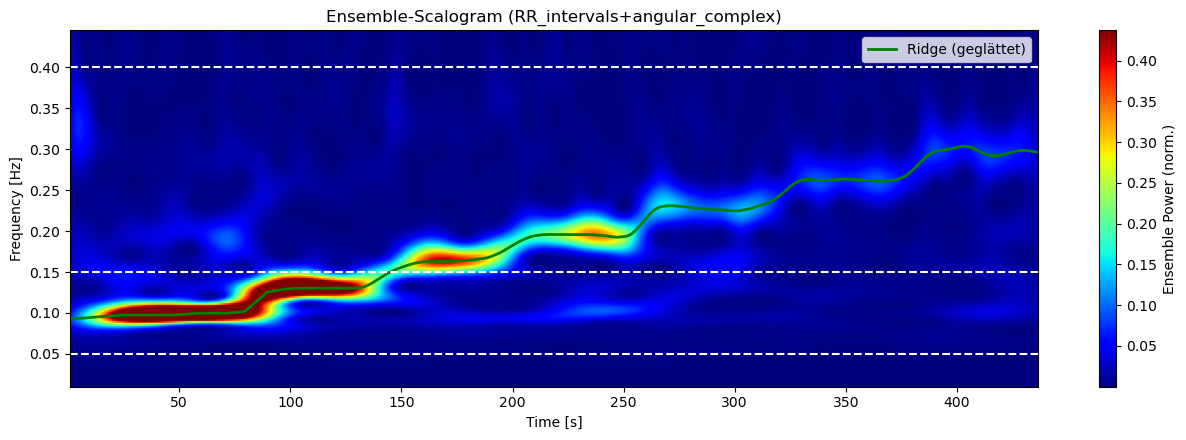

In [32]:
t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax = \
    compute_scalogram_and_ridge(
        df_results_clean,
        signal_cols=["RR_intervals", "angular_complex"],
        time_col="Time",
        plot_scalogram=True
    )


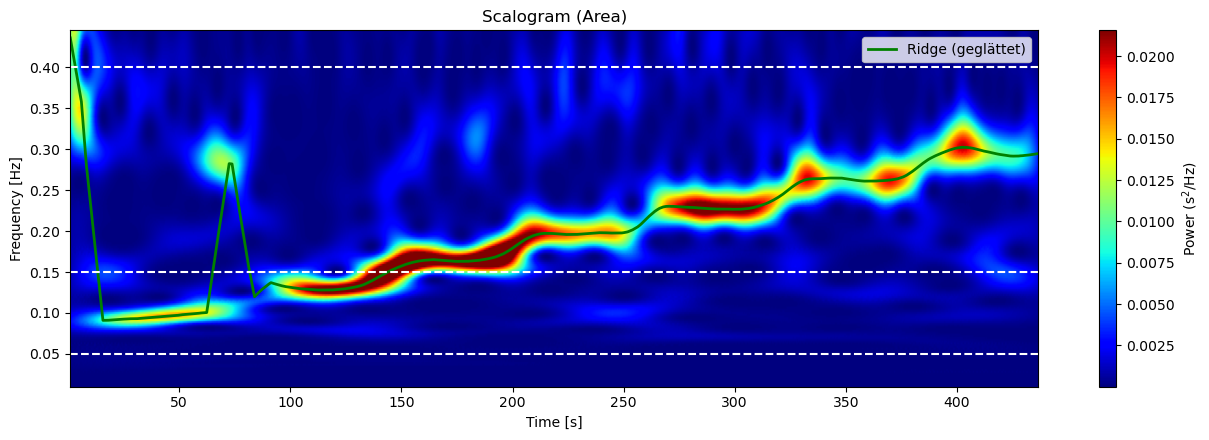

In [33]:

t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax = \
    compute_scalogram_and_ridge(
        df_results_clean,
        signal_cols=["Area"],
        time_col="Time",
        plot_scalogram=True
    )

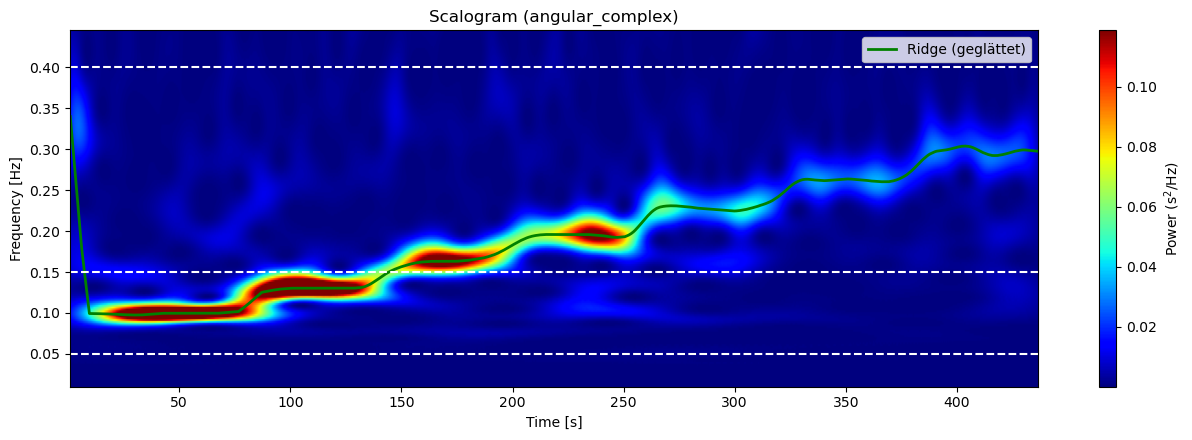

In [34]:
t_uniform, y_detrended, freqs, power, freq_ridge_smooth, imax = \
    compute_scalogram_and_ridge(
        df_results_clean,
        signal_cols=["angular_complex"],
        time_col="Time",
        plot_scalogram=True
    )


In [35]:
# Füge Atemfrequenz-Verlauf als neue Spalte zu df_results_clean hinzu
df_results_clean['respiration_frequency_hz'] = np.nan

# Interpoliere freq_ridge_smooth auf die originalen Zeitpunkte von df_results_clean
interp_freq = interp1d(t_uniform, freq_ridge_smooth, 
                      kind='linear', bounds_error=False, fill_value=np.nan)

# Schreibe Werte in die neue Spalte (Zeitachsen müssen übereinstimmen)
mask_valid_time = (df_results_clean['Time'] >= t_uniform[0]) & (df_results_clean['Time'] <= t_uniform[-1])
df_results_clean.loc[mask_valid_time, 'respiration_frequency_hz'] = interp_freq(df_results_clean.loc[mask_valid_time, 'Time'])

# Optional: Auch in BPM speichern
df_results_clean['respiration_frequency_bpm'] = df_results_clean['respiration_frequency_hz'] * 60.0

print(f"Atemfrequenz-Verlauf hinzugefügt: {np.sum(~df_results_clean['respiration_frequency_hz'].isna())} von {len(df_results_clean)} Zeilen gefüllt.")
print(f"Min: {df_results_clean['respiration_frequency_hz'].min():.3f} Hz, Max: {df_results_clean['respiration_frequency_hz'].max():.3f} Hz")


Atemfrequenz-Verlauf hinzugefügt: 549 von 550 Zeilen gefüllt.
Min: 0.097 Hz, Max: 0.340 Hz


In [36]:
display(df_results_clean.head())

# Extrahiere Proband ID und erstelle Dateinamen
subject_id = f"S{PROBAND_ID}"
filename = f"HRV_Respiration_{PROBAND_ID}.csv"

# Wähle und benenne die gewünschten Spalten um
columns_to_save = df_results_clean[
    ["Time", "RR_intervals", "r", "angular_complex", "angular_complex_angle", "respiration_frequency_hz", "respiration_frequency_bpm"]
].rename(columns={
    "r": "R_Amplitude",
    "angular_complex": "Heartmovement_amplitude", 
    "angular_complex_angle": "Heartmovement_phase"
})

# Speichere als CSV
columns_to_save.to_csv(filename, index=False)
print(f"Daten erfolgreich als {filename} gespeichert ({len(columns_to_save)} Zeilen).")


,Time,RR_intervals,amplitude_changes,1D_R_Amplitude,Area,Normal_Angle,r,phi,theta,angular_complex,angular_complex_angle,respiration_frequency_hz,respiration_frequency_bpm
0,0.992,0.780,0.008681,0.525613,0.879276,105.518084,0.722055,0.875782,1.246214,1.523169,0.958224,0.339758,20.385502
1,1.816,0.824,-0.034076,0.507065,0.703754,81.361475,0.687980,0.907142,1.210024,1.512305,0.927494,0.313745,18.824691
2,2.648,0.832,0.021678,0.629632,0.968568,100.372043,0.709657,1.325995,1.154267,1.758009,0.716271,0.287479,17.248726
3,3.456,0.808,-0.004558,0.602148,0.718178,81.448780,0.705099,1.162336,1.195890,1.667686,0.799626,0.261970,15.718221
4,4.312,0.856,0.014989,0.574220,0.777401,114.456469,0.720088,1.023560,1.204878,1.580951,0.866585,0.234947,14.096795


Daten erfolgreich als HRV_Respiration_55.csv gespeichert (550 Zeilen).
